In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 928.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

!unzip "/content/drive/MyDrive/Brain_tumot_preporcessed.zip"

Archive:  /content/drive/MyDrive/Brain_tumot_preporcessed.zip
   creating: content/pp1/
   creating: content/pp1/brain_glioma/
  inflating: content/pp1/brain_glioma/brain_glioma_0556.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1383.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1094.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_0838.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_0292.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1522.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1302.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1286.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_0795.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_0854.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1919.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_0670.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_0794.jpg  
  inflating: content/pp1/brain_glioma/brain_glioma_1940.jpg  
  inf

In [4]:
base_dir = "/content/content/pp1"

In [5]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['brain_glioma', 'brain_menin', 'brain_tumor']


In [6]:
len(folders)

3

In [7]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):
  """
  Counts the number of images in a directory and its subdirectories.

  Args:
    root_directory: The root directory to count images in.

  Returns:
    A dictionary where the keys are the subdirectories and the values are the number of images in each subdirectory.
  """

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = base_dir
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: brain_glioma, Image count: 500
Subdirectory: brain_menin, Image count: 500
Subdirectory: brain_tumor, Image count: 500


In [8]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 5000
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)

Augmenting images in /content/content/pp1/brain_glioma: 100%|██████████| 500/500 [00:27<00:00, 18.49it/s]


Augmentation complete for /content/content/pp1/brain_glioma. Total images in '/content/augmented/brain_glioma': 5000


Augmenting images in /content/content/pp1/brain_menin: 100%|██████████| 500/500 [00:13<00:00, 36.66it/s]


Augmentation complete for /content/content/pp1/brain_menin. Total images in '/content/augmented/brain_menin': 5000


Augmenting images in /content/content/pp1/brain_tumor: 100%|██████████| 500/500 [00:13<00:00, 36.60it/s]


Augmentation complete for /content/content/pp1/brain_tumor. Total images in '/content/augmented/brain_tumor': 5000


In [9]:
base_dir="/content/augmented"

In [10]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [11]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [12]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.


In [13]:
test_labels = np.array(test_generator.labels)

In [14]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionResNetV2, MobileNetV2

# Custom GroupNormalization layer
class GroupNormalization(layers.Layer):
    def __init__(self, groups=32, **kwargs):
        super(GroupNormalization, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],),
                                     initializer='ones', trainable=True)
        self.offset = self.add_weight(name='offset', shape=(input_shape[-1],),
                                      initializer='zeros', trainable=True)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        group_shape = tf.concat([input_shape[:-1], [self.groups, input_shape[-1] // self.groups]], axis=0)
        grouped_inputs = tf.reshape(inputs, group_shape)
        mean, variance = tf.nn.moments(grouped_inputs, [1, 2], keepdims=True)
        normalized_inputs = (grouped_inputs - mean) / tf.sqrt(variance + 1e-5)
        normalized_inputs = tf.reshape(normalized_inputs, input_shape)
        return normalized_inputs * self.scale + self.offset

# Define the model creation function
def create_inceptionresnet_mobilenet_model(input_shape, num_classes):
    # Load InceptionResNetV2 and MobileNetV2 models
    InceptionResNetV2_model = InceptionResNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
    MobileNetV2_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

    # Freeze the pre-trained models
    InceptionResNetV2_model.trainable = False
    MobileNetV2_model.trainable = False

    # Input layer
    input_layer = Input(shape=input_shape)

    # Extract features
    InceptionResNetV2_features = InceptionResNetV2_model(input_layer)
    MobileNetV2_features = MobileNetV2_model(input_layer)

    # Global average pooling
    InceptionResNetV2_pooled = layers.GlobalAveragePooling2D()(InceptionResNetV2_features)
    MobileNetV2_pooled = layers.GlobalAveragePooling2D()(MobileNetV2_features)

    # Concatenate features
    combined_features = layers.Concatenate()([InceptionResNetV2_pooled, MobileNetV2_pooled])

    # Add GroupNormalization and Dense layers
    x = Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)
    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.BatchNormalization()(x)
    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.2)(x)
    x = GroupNormalization()(x)

    # Output layer
    output_layer = Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

# Define the input shape and number of classes
input_shape = (224, 224, 3)  # Example input shape for RGB images
num_classes = 3  # Example number of output classes

# Create the model
model = create_inceptionresnet_mobilenet_model(input_shape, num_classes)

# Print model summary
model.summary()


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


<ipython-input-14-fb83f76c2d61>:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  MobileNetV2_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inception_resnet_v2       │ (None, 5, 5, 1536)     │     54,336,736 │ input_layer_2[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mobilenetv2_1.00_224      │ (None, 7, 7, 1280)     │      2,257,984 │ input_layer_2[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 1536)           │              0 │ inception_resnet_v2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1280)           │              0 │ mobilenetv2_1.00_224[… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 2816)           │              0 │ global_average_poolin… │
│                           │                        │                │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 2816)           │              0 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_203   │ (None, 2816)           │         11,264 │ flatten[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │        360,576 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_204   │ (None, 128)            │            512 │ dropout[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │         16,512 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_205   │ (None, 128)            │            512 │ dropout_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │         16,512 │ batch_normalization_2… │
├──────────────────────

 Total params: 57,001,251 (217.44 MB)

 Trainable params: 400,387 (1.53 MB)

 Non-trainable params: 56,600,864 (215.92 MB)

In [15]:
input_shape = (224, 224, 3)  # Input image shape
num_classes = 3  # Number of output classes


model = create_inceptionresnet_mobilenet_model(input_shape, num_classes)

optim = keras.optimizers.AdamW(
    learning_rate=0.0001,
    weight_decay=0.006,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=True,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adamw"
)

model.compile(
    optimizer=optim,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

<ipython-input-14-fb83f76c2d61>:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  MobileNetV2_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inception_resnet_v2       │ (None, 5, 5, 1536)     │     54,336,736 │ input_layer_5[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mobilenetv2_1.00_224      │ (None, 7, 7, 1280)     │      2,257,984 │ input_layer_5[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1536)           │              0 │ inception_resnet_v2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1280)           │              0 │ mobilenetv2_1.00_224[… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 2816)           │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 2816)           │              0 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_409   │ (None, 2816)           │         11,264 │ flatten_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │        360,576 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_410   │ (None, 128)            │            512 │ dropout_3[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 128)            │         16,512 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 128)            │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_411   │ (None, 128)            │            512 │ dropout_4[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │         16,512 │ batch_normalization_4… │
├──────────────────────

 Total params: 57,001,251 (217.44 MB)

 Trainable params: 400,387 (1.53 MB)

 Non-trainable params: 56,600,864 (215.92 MB)

In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


165/165 ━━━━━━━━━━━━━━━━━━━━ 205s 790ms/step - accuracy: 0.5035 - loss: 1.1819 - val_accuracy: 0.7449 - val_loss: 0.7556 - learning_rate: 1.0000e-04
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 107s 439ms/step - accuracy: 0.6913 - loss: 0.7456 - val_accuracy: 0.8338 - val_loss: 0.5022 - learning_rate: 1.0000e-04
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 81s 437ms/step - accuracy: 0.7560 - loss: 0.6180 - val_accuracy: 0.8618 - val_loss: 0.4218 - learning_rate: 1.0000e-04
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 82s 435ms/step - accuracy: 0.7859 - loss: 0.5574 - val_accuracy: 0.8791 - val_loss: 0.3728 - learning_rate: 1.0000e-04
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 72s 431ms/step - accuracy: 0.8144 - loss: 0.4972 - val_accuracy: 0.8871 - val_loss: 0.3462 - learning_rate: 1.0000e-04
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 72s 431ms/step - accuracy: 0.8248 - loss: 0.4548 - val_accuracy: 0.8916 - val_loss: 0.3150 - learning_rate: 1.0000e-04
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 72s 432ms/step 

In [17]:
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 341ms/step - accuracy: 0.9505 - loss: 0.1615
Test Loss: 0.1540
Test Accuracy: 0.9484


<Figure size 640x480 with 0 Axes>

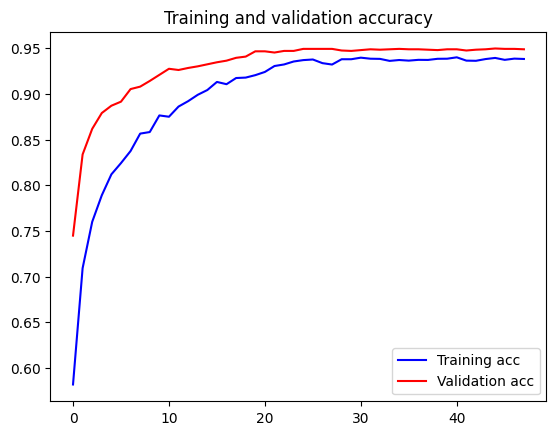

<Figure size 640x480 with 0 Axes>

In [18]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

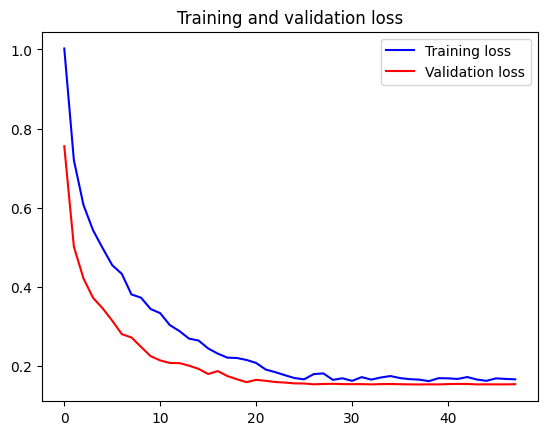

In [19]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 703ms/step


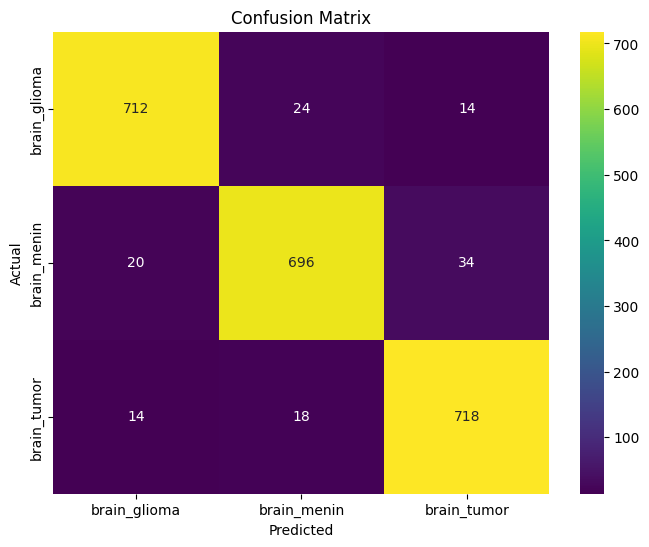

Precision: 0.9666666666666667
Recall: 0.9720670391061452
F1 Score: 0.9693593314763231


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step


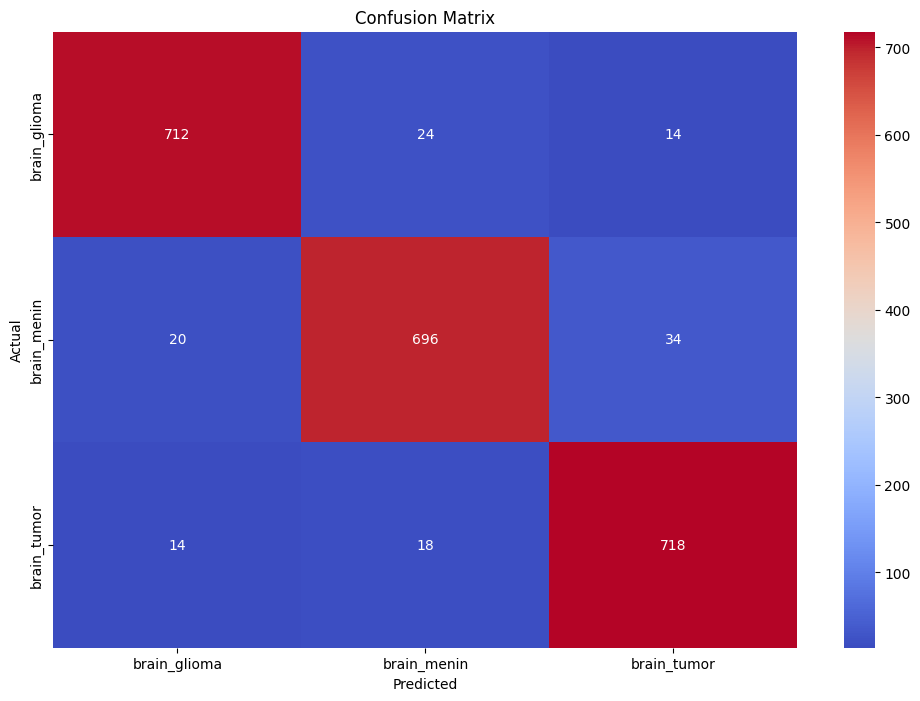

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



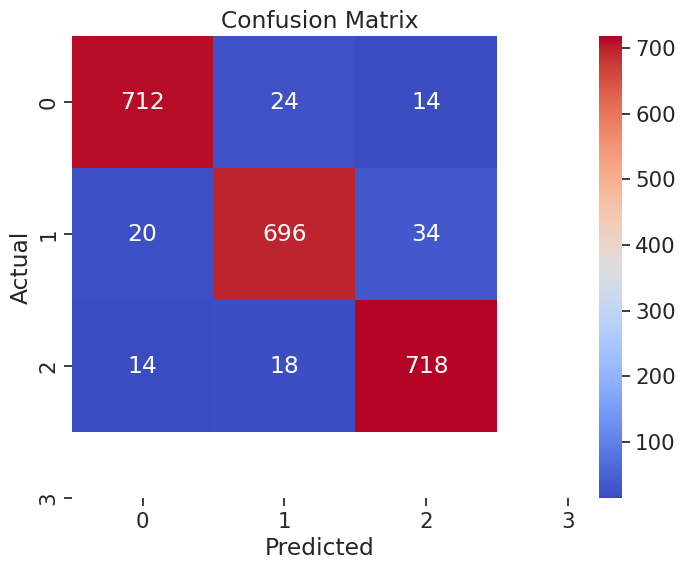

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


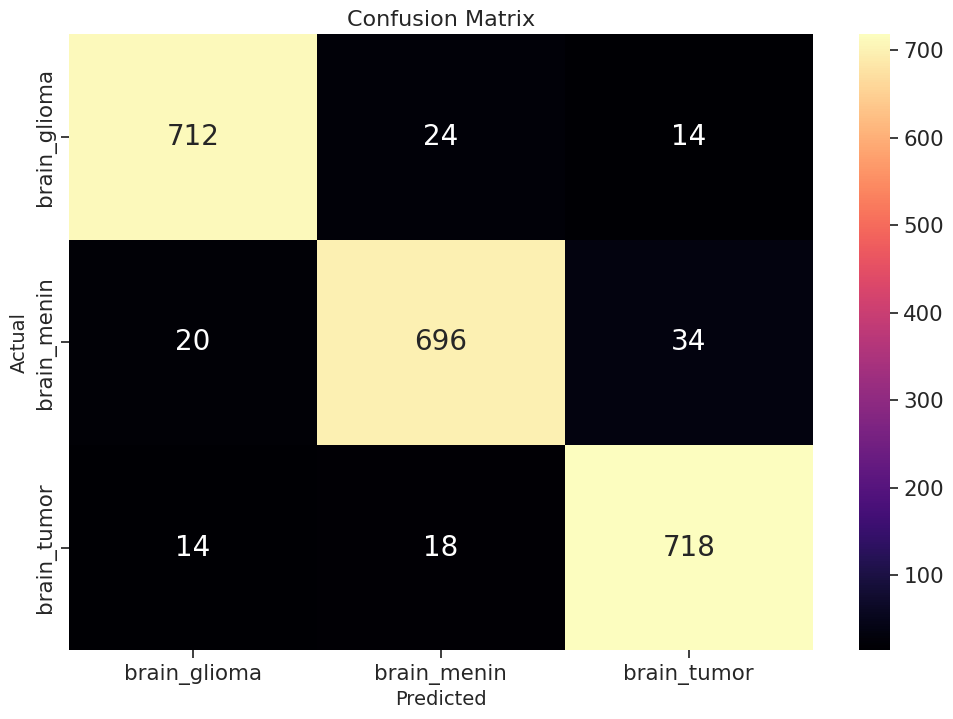

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [24]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

In [25]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.95      0.95      0.95       750
           1       0.94      0.93      0.94       750
           2       0.94      0.96      0.95       750

    accuracy                           0.94      2250
   macro avg       0.94      0.94      0.94      2250
weighted avg       0.94      0.94      0.94      2250



<Figure size 640x480 with 0 Axes>

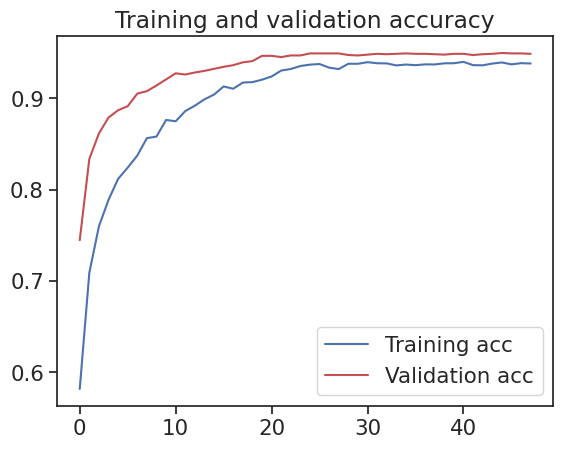

<Figure size 640x480 with 0 Axes>

In [26]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

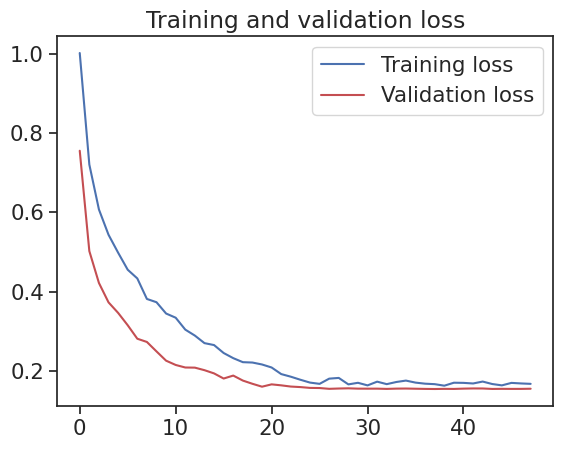

In [27]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

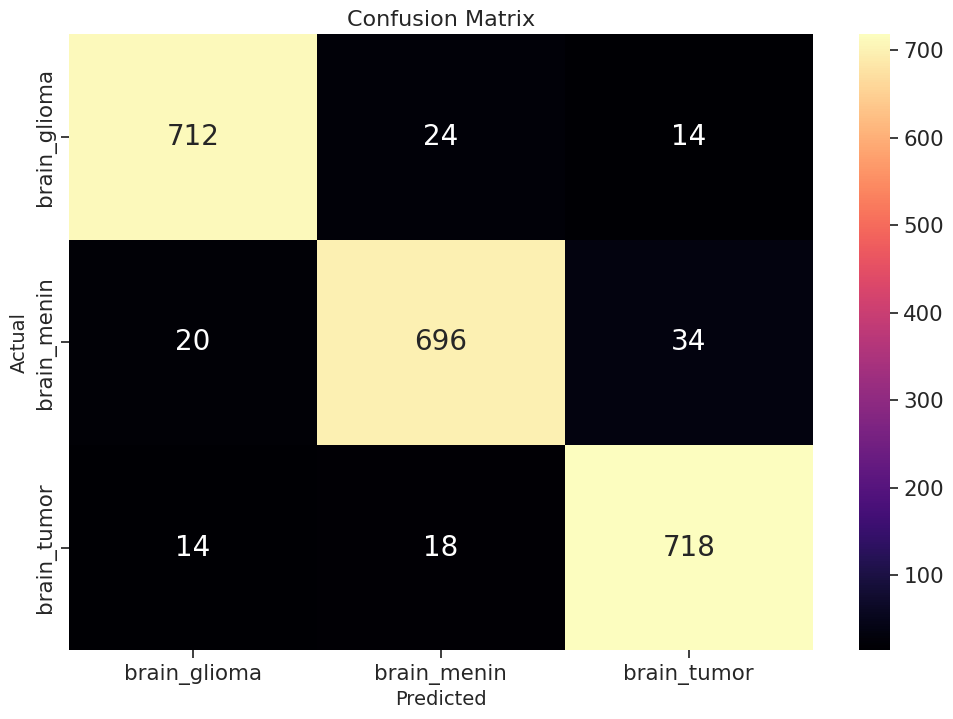

In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step


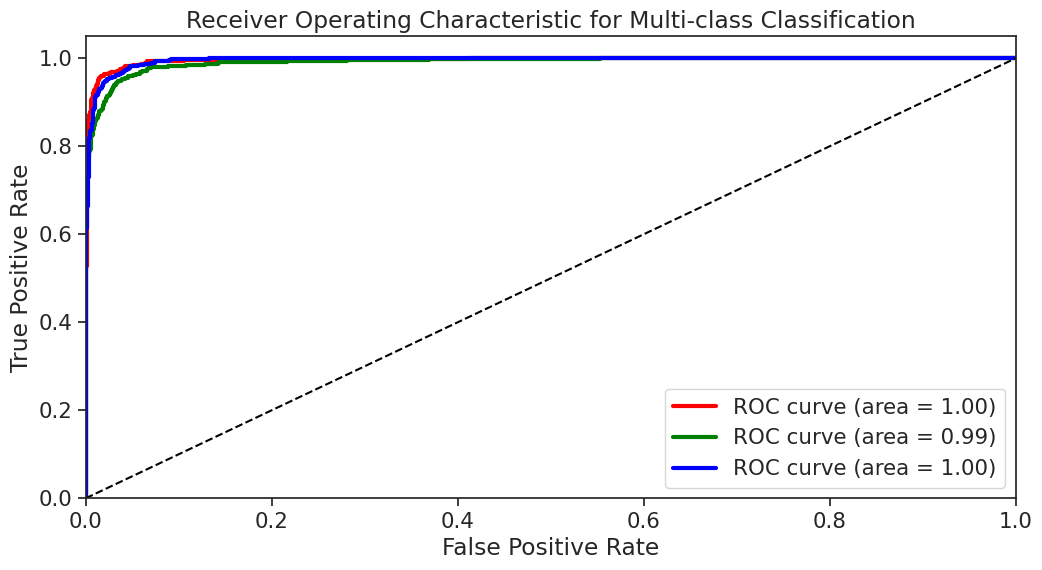

AUC scores:
Class 1: 0.9959671111111112
Class 2: 0.9912319999999999
Class 3: 0.9954675555555555


In [29]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 3  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow', 'purple', 'cyan']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


In [30]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 339ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 321ms/step
Class brain_glioma:
Precision: 0.9544
Recall: 0.9493
F1-score: 0.9519

Class brain_menin:
Precision: 0.9431
Recall: 0.9280
F1-score: 0.9355

Class brain_tumor:
Precision: 0.9373
Recall: 0.9573
F1-score: 0.9472



In [31]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step
              precision    recall  f1-score   support

brain_glioma       0.95      0.95      0.95       750
 brain_menin       0.94      0.93      0.94       750
 brain_tumor       0.94      0.96      0.95       750

    accuracy                           0.94      2250
   macro avg       0.94      0.94      0.94      2250
weighted avg       0.94      0.94      0.94      2250



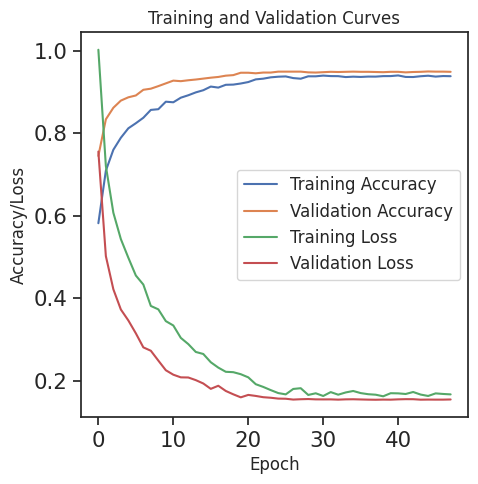

In [32]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step


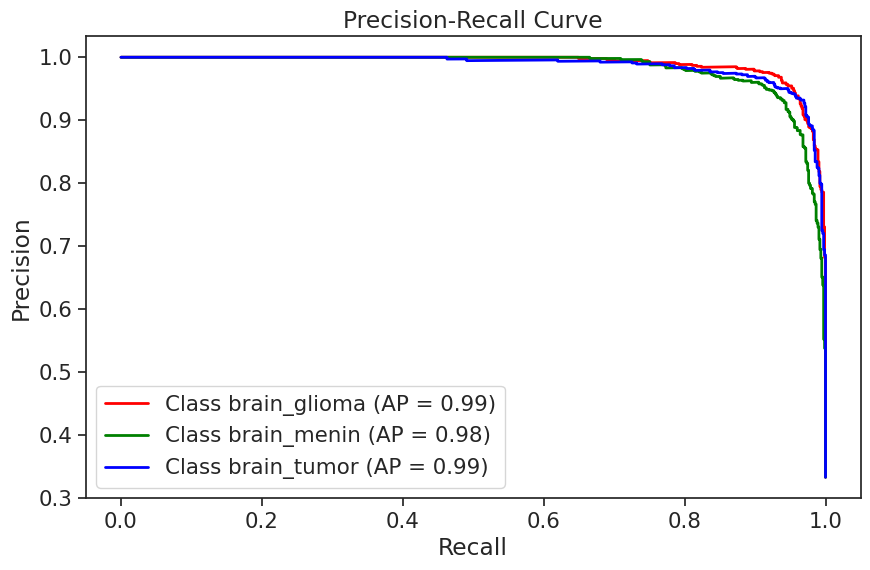

In [33]:
# prompt: create PR curve

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Get predicted probabilities for each class
y_probs = model.predict(test_generator)

# Get the true labels
y_true = test_generator.classes

# Calculate precision-recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

n_classes = len(classes)

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        (y_true == i).astype(int), y_probs[:, i]
    )
    average_precision[i] = average_precision_score(
        (y_true == i).astype(int), y_probs[:, i]
    )

# Plot the PR curve for each class
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow', 'purple', 'cyan']
for i, color in zip(range(n_classes), colors):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        color=color,
        label=f"Class {classes[i]} (AP = {average_precision[i]:.2f})",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


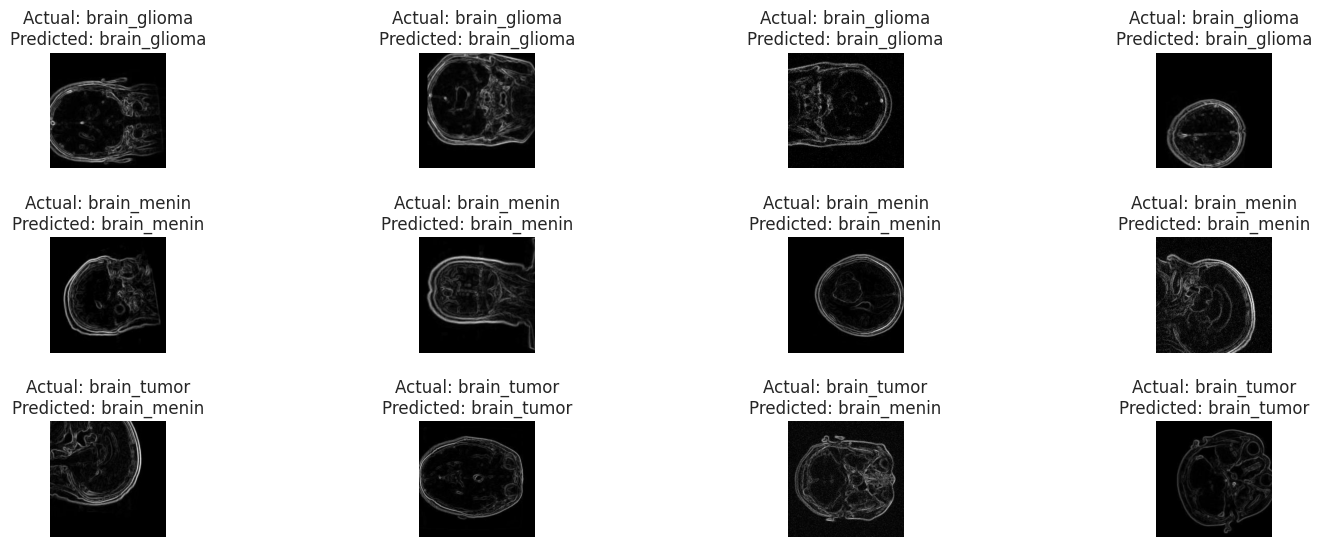

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Assuming test_generator is your test data generator and model is your trained model

# Number of classes and images per class
num_classes = 3
num_images_per_class = 4
num_images_to_display = num_classes * num_images_per_class

# Reset the test generator to the start
test_generator.reset()

# Get the class names from the test generator
class_names = list(test_generator.class_indices.keys())

# Initialize lists to store images and labels
images_to_display = []
labels_to_display = []

# Dictionary to track the number of images collected per class
collected_counts = {class_name: 0 for class_name in class_names}

# Loop to collect images from each class
while len(images_to_display) < num_images_to_display:
    images, labels = next(test_generator)
    indices = list(range(len(images)))
    random.shuffle(indices)  # Shuffle indices to select random images

    for i in indices:
        class_index = np.argmax(labels[i])  # Get the class index
        class_label = class_names[class_index]  # Get the class name

        # Check if we've already collected enough images for this class
        if collected_counts[class_label] < num_images_per_class:
            images_to_display.append(images[i])
            labels_to_display.append(labels[i])
            collected_counts[class_label] += 1

        # Stop if we've collected enough images
        if len(images_to_display) >= num_images_to_display:
            break

# Convert the lists to numpy arrays
images_to_display = np.array(images_to_display)
labels_to_display = np.array(labels_to_display)

# Make predictions for the selected images
predictions = model.predict(images_to_display)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(labels_to_display, axis=1)

# Plot the images with actual and predicted labels
plt.figure(figsize=(15, 15))  # Adjust figure size
for i in range(num_images_to_display):
    plt.subplot(8, 4, i + 1)  # 8 rows and 4 columns to accommodate 32 images
    plt.imshow(images_to_display[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [35]:
# Reset the test generator to start
test_generator.reset()

# Generate predictions on the entire test set
predictions = model.predict(test_generator)

# Get the true labels for the entire test set
test_labels = test_generator.classes

# Convert predictions to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Calculate the confusion matrix and performance metrics
cm = confusion_matrix(test_labels, predicted_labels)

# Extract true positive (TP), true negative (TN), false positive (FP), and false negative (FN) counts
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Calculate sensitivity (recall) and specificity
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step
Sensitivity (Recall): 0.9721
Specificity: 0.9674


In [36]:
# prompt: create cohen kappa score

from sklearn.metrics import cohen_kappa_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities

# Convert predictions to class indices
predicted_labels = np.argmax(model.predict(test_generator), axis=1)

# Calculate Cohen's Kappa score
kappa = cohen_kappa_score(test_generator.classes, predicted_labels)

print(f"Cohen's Kappa Score: {kappa:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 347ms/step
Cohen's Kappa Score: 0.9173


In [37]:
# prompt: create false positive rate

from sklearn.metrics import confusion_matrix

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities

# Convert predictions to class indices
predicted_labels = np.argmax(model.predict(test_generator), axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(test_generator.classes, predicted_labels)

# Extract true negative (TN), false positive (FP), false negative (FN), and true positive (TP)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# False positive rate (FPR)
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"False Positive Rate: {FPR:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 341ms/step
False Positive Rate: 0.0326


In [38]:
# prompt: create false negative rate

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities

# Convert predictions to class indices
predicted_labels = np.argmax(model.predict(test_generator), axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(test_generator.classes, predicted_labels)

# Extract true negative (TN), false positive (FP), false negative (FN), and true positive (TP)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# False negative rate (FNR)
FNR = FN / (FN + TP) if (FN + TP) > 0 else 0

print(f"False Negative Rate: {FNR:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 332ms/step
False Negative Rate: 0.0279


In [39]:
# prompt: create true postive rate

from sklearn.metrics import confusion_matrix

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities

# Convert predictions to class indices
predicted_labels = np.argmax(model.predict(test_generator), axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(test_generator.classes, predicted_labels)

# Extract true negative (TN), false positive (FP), false negative (FN), and true positive (TP)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# True positive rate (TPR) or sensitivity or recall
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"True Positive Rate (TPR): {TPR:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step
True Positive Rate (TPR): 0.9721


In [40]:
# prompt: create true negetive rate

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities

# Convert predictions to class indices
predicted_labels = np.argmax(model.predict(test_generator), axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(test_generator.classes, predicted_labels)

# Extract true negative (TN), false positive (FP), false negative (FN), and true positive (TP)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# True negative rate (TNR) or specificity
TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"True Negative Rate (TNR): {TNR:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 321ms/step
True Negative Rate (TNR): 0.9674


In [41]:
# prompt: create log loss

from sklearn.metrics import log_loss

# Assuming 'predictions' contains predicted probabilities for each class
# and 'test_labels' contains the true labels (one-hot encoded)

# Calculate log loss
logloss = log_loss(test_labels_bin, predictions)

print(f"Log Loss: {logloss:.4f}")

Log Loss: 0.1847


In [42]:
# prompt: create mathew correlation corelation coeeficient

import numpy as np
from scipy.stats import pearsonr

# Assuming 'predicted_labels' are your model's predictions and 'test_labels' are the true labels
# Both should be NumPy arrays of the same length

# Calculate the Matthews Correlation Coefficient (MCC)
def matthews_correlation(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return mcc

mcc = matthews_correlation(test_labels, predicted_labels)

print("Matthews Correlation Coefficient:", mcc)


# Calculate the Pearson Correlation Coefficient
correlation, p_value = pearsonr(test_labels, predicted_labels)

print("Pearson Correlation Coefficient:", correlation)
print("P-value:", p_value)


Matthews Correlation Coefficient: 0.9394013011427708
Pearson Correlation Coefficient: 0.9310050179069004
P-value: 0.0


In [43]:
# prompt: create f2 score

from sklearn.metrics import f1_score

# Assuming predicted_labels and test_labels are defined as in your previous code

# Calculate the f2 score
f2 = f1_score(test_labels, predicted_labels, average='weighted') # or 'macro', 'micro' depending on your needs
print(f"F2 Score: {f2}")

F2 Score: 0.94486169339098


In [44]:
# prompt: create f0.5 score

from sklearn.metrics import fbeta_score

# Assuming predicted_labels and test_labels are defined as in your previous code

# Calculate the f0.5 score
f05 = fbeta_score(test_labels, predicted_labels, beta=0.5, average='weighted') # or 'macro', 'micro' depending on your needs
print(f"F0.5 Score: {f05}")

F0.5 Score: 0.9449008673954638


In [45]:
# prompt: create and show jaccard index

import numpy as np

def jaccard_index(set1, set2):
  intersection = len(set1.intersection(set2))
  union = len(set1.union(set2))
  if union == 0:
    return 0  # Handle the case where both sets are empty
  return intersection / union

# Example usage:
set1 = {1, 2, 3}
set2 = {2, 3, 4}

jaccard = jaccard_index(set1, set2)
print(f"Jaccard index: {jaccard}")


# Example with numpy arrays:
array1 = np.array([1, 2, 3, 4, 5])
array2 = np.array([3, 5, 6, 7, 8])

set1_np = set(array1)
set2_np = set(array2)
jaccard_np = jaccard_index(set1_np, set2_np)
print(f"Jaccard Index (numpy arrays): {jaccard_np}")

Jaccard index: 0.5
Jaccard Index (numpy arrays): 0.25


In [46]:
# prompt: create and show hamming loss

from sklearn.metrics import hamming_loss

# Assuming predicted_labels and test_labels are defined as in your previous code
# Calculate the Hamming loss
hamming_loss_value = hamming_loss(test_labels, predicted_labels)

print(f"Hamming Loss: {hamming_loss_value}")

Hamming Loss: 0.05511111111111111


In [47]:
# prompt: create  top k accuracy

import numpy as np
from sklearn.metrics import top_k_accuracy_score

# Assuming you have predictions (probabilities) and true labels
# predictions: a NumPy array of shape (n_samples, n_classes)
# test_labels: a NumPy array of shape (n_samples,) with true class labels

# Example:
# predictions = model.predict(test_generator)
# test_labels = test_generator.classes

# Calculate top-k accuracy for k=3
top_3_accuracy = top_k_accuracy_score(test_labels, predictions, k=3)

print(f"Top-3 accuracy: {top_3_accuracy}")

Top-3 accuracy: 1.0


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:2025: UndefinedMetricWarning: 'k' (3) greater than or equal to 'n_classes' (3) will result in a perfect score and is therefore meaningless.
  warnings.warn(


In [48]:
# prompt: show foulkes mallows index

from sklearn.metrics import fowlkes_mallows_score

# Assuming predicted_labels and test_labels are defined as in your previous code
# Calculate the Foulkes-Mallows index
fowlkes_mallows_index = fowlkes_mallows_score(test_labels, predicted_labels)

print(f"Foulkes-Mallows Index: {fowlkes_mallows_index}")

Foulkes-Mallows Index: 0.8944049697347752


In [49]:
# prompt: save the model in .h5

model.save('Brain Tumor.h5')
